**Netflix Movies (2010–2025): Global Representation, Audience Engagement, and Financial Performance**

**Project Objective**

Netflix serves a global audience, but global reach does not always mean that movies are equally represented across countries, languages, and genres. 
This project analyzes whether the Netflix movie dataset is dominated by a small group of countries and content types, and examines
how audience engagement and financial performance vary across films.

**Dataset**

This analysis uses a Kaggle dataset containing 16,000 movie records from 2010 to 2025.

The dataset includes movie title, country, language, genres, release year, audience ratings, vote counts, popularity, budget, and revenue.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\netflix_movies_detailed_up_to_2025.csv")
df.isna().sum()

show_id             0
type                0
title               0
director          132
cast              204
country           466
date_added          0
release_year        0
rating              0
duration        16000
genres            107
language            0
description       132
popularity          0
vote_count          0
vote_average        0
budget              0
revenue             0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  str    
 2   title         16000 non-null  str    
 3   director      15868 non-null  str    
 4   cast          15796 non-null  str    
 5   country       15534 non-null  str    
 6   date_added    16000 non-null  str    
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  str    
 11  language      16000 non-null  str    
 12  description   15868 non-null  str    
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), str(9)
memor

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


In [6]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
15995,1440286,Movie,Festival de Viña del Mar 2025: Ha*Ash,NaN,Ha*ash,Chile,2025-02-24,2025,0.0,NaN,Music,es,NaN,4.931,0,0.0,0,0
15996,1271724,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.0,NaN,Drama,ru,Poignant stories about men and women who have ...,4.930,0,0.0,0,0
15997,1426364,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",NaN,2025-01-28,2025,1.0,NaN,Horror,en,Two villainous entities initiate gorgeous soro...,4.922,1,1.0,0,0
15998,1411248,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",NaN,2025-03-10,2025,0.0,NaN,NaN,en,A Dunces Burden,4.921,0,0.0,0,0
15999,1405742,Movie,Portal to Hell,Woody Bess,"Trey Holland, Keith David, Richard Kind, Micha...",United States of America,2025-02-22,2025,0.0,NaN,"Comedy, Horror",en,After a debt-collector finds a portal to hell ...,4.921,0,0.0,0,0


In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'language',
       'description', 'popularity', 'vote_count', 'vote_average', 'budget',
       'revenue'],
      dtype='str')

**Data Cleaning**

The duration column was removed because all of its values were missing. Missing values in director, cast, country, genre, and plot description were replaced with Unknown where appropriate.

In [59]:
# Let's Do some cleaning of Our dataset
df=df.drop(columns='duration')
df['director']=df['director'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')
df['cast']=df['cast'].fillna('Unknown')
df.rename(columns={'date_added':'release_date','description':'plot'},inplace=True)
df['director']=df['director'].str.strip()
df['genres']=df['genres'].fillna('Unknown')
df['plot']=df['plot'].fillna('Unknown')
df.head(3)

,show_id,type,title,director,cast,country,release_date,release_year,rating,genres,language,plot,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868


In [60]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
release_date    0
release_year    0
rating          0
genres          0
language        0
plot            0
popularity      0
vote_count      0
vote_average    0
budget          0
revenue         0
dtype: int64

End of Data Cleaning; Now that all of cleaning has been done, Let's copy the data into the new varable to perform Feature Engineering

In [58]:
# Now that we are done data cleaning Let's shift the focus to Feature Engineering
df_new=df.copy()
df_new['Primary_Country']=df['country'].str.split(',').str[0]
Country_Count=df_new.groupby('Primary_Country')['show_id'].count()
Country_Count.sort_values(ascending=False).head(10)


Primary_Country
United States of America    5699
United Kingdom              1050
France                      1030
Canada                       932
Japan                        914
South Korea                  818
India                        489
Unknown                      466
Belgium                      460
China                        415
Name: show_id, dtype: int64

In [13]:
df_new['Primary_Genre']=df_new['genres'].str.split(',').str[0]
Genre_Count=df_new.groupby('Primary_Genre')['show_id'].count()
Genre_Count.sort_values(ascending=False).head(10) 

Primary_Genre
Drama              3634
Comedy             2352
Action             1883
Horror             1520
Animation          1117
Thriller            961
Romance             914
Documentary         808
Crime               487
Science Fiction     416
Name: show_id, dtype: int64

In [14]:
df_new['release_year']=pd.to_numeric(df['release_year'],errors="coerce")
df_new['Period']=pd.cut(df_new['release_year'],bins=[2009,2014,2019,2025],labels=['2010-14','2015-19','2020-25'],include_lowest=True)
df_new.groupby('Period')['show_id'].count().sort_values(ascending=False) 

Period
2020-25    6000
2010-14    5000
2015-19    5000
Name: show_id, dtype: int64

In [15]:
top_languages=df_new['language'].value_counts().head(8).index
df_new['language_group']=df['language'].where(df['language'].isin(top_languages),'Other')
df_new.head(3)

,show_id,type,title,director,cast,country,release_date,release_year,rating,duration,...,plot,popularity,vote_count,vote_average,budget,revenue,Primary_Country,Primary_Genre,Period,language_group
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,...,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867,United States of America,Comedy,2010-14,en
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,...,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630,United Kingdom,Action,2010-14,en
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,...,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868,United Kingdom,Adventure,2010-14,en


In [16]:
conditions= [
    df['rating'] < 5.0,
    df['rating'].between(5.0, 6.9),
    df['rating'].between(7.0,7.9),
    df['rating'] > 8.0
]
ch=['Underwhelming','Entertaining','Must Watch','Masterpeice']
df_new['Rating_category']=np.select(conditions,ch,default='Unknown')
df_new.head(2)

,show_id,type,title,director,cast,country,release_date,release_year,rating,duration,...,popularity,vote_count,vote_average,budget,revenue,Primary_Country,Primary_Genre,Period,language_group,Rating_category
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,...,203.893,7449,6.380,165000000,752600867,United States of America,Comedy,2010-14,en,Entertaining
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,...,156.242,37119,8.369,160000000,839030630,United Kingdom,Action,2010-14,en,Masterpeice


In [17]:
df_new['Rev_bud']=(df['budget']!=0) & (df['revenue']!=0)
df_new['Rev_bud'].value_counts()

Rev_bud
False    12460
True      3540
Name: count, dtype: int64

In [18]:
df_new["Profit"] = np.nan

df_new.loc[df_new["Rev_bud"], "Profit"] = (
    df_new.loc[df_new["Rev_bud"], "revenue"] -
    df_new.loc[df_new["Rev_bud"], "budget"]
)
df_new["Profit"].notna().sum()

np.int64(3540)

In [19]:
df_new['Roi_Percent']=np.nan

df_new.loc[df_new['Rev_bud'],'Roi_Percent']=(
    (df_new.loc[df_new['Rev_bud'],'Profit']/
    df_new.loc[df_new['Rev_bud'],'budget'])*100
)
df_new['Roi_Percent'].describe()

count    3.540000e+03
mean     7.805457e+04
std      4.155657e+06
min     -9.999922e+01
25%     -4.786957e+01
50%      7.000329e+01
75%      2.760963e+02
max      2.456759e+08
Name: Roi_Percent, dtype: float64

In [20]:
df_new['budget_band']="No financial data"

df_new.loc[df_new['Rev_bud'],'budget_band']=pd.qcut(df_new.loc[df_new['Rev_bud'],'budget'],q=3,labels=['Low budget','Medium budget','High budget'],duplicates='drop')
df_new["budget_band"].value_counts()

budget_band
No financial data    12460
Medium budget         1280
Low budget            1182
High budget           1078
Name: count, dtype: int64

In [21]:
df_new['vote_engagement']=np.log1p(df_new['vote_count'])
df_new[["vote_count", "vote_engagement"]].describe()

,vote_count,vote_engagement
count,16000.000000,16000.000000
mean,718.656125,4.850574
std,2080.198316,2.045009
min,0.000000,0.000000
25%,53.000000,3.988984
50%,138.000000,4.934474
75%,422.000000,6.047372
max,37119.000000,10.521911


In [22]:
df_new['Release_Age']=2026 - df_new['release_year']

**Feature Engineering**

To support the analysis, new variables were created:

**Primary_Country** and **Primary_Genre** simplify multi-country and multi-genre entries for comparison.

**Period** groups films into 2010–14, 2015–19, and 2020–25.

**Rating_Category** Categorizes Movies based on the ratings. ('Underwhelming','Entertaining','Must Watch','Masterpeice')

**language_group** keeps the most common languages while grouping less common languages as Other.

**vote_engagement** applies a logarithmic transformation to vote count.

**Profit**, **Roi_Percent**, and **budget_band** support financial-performance analysis.

In [23]:
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   show_id          16000 non-null  int64   
 1   type             16000 non-null  str     
 2   title            16000 non-null  str     
 3   director         16000 non-null  str     
 4   cast             16000 non-null  str     
 5   country          16000 non-null  str     
 6   release_date     16000 non-null  str     
 7   release_year     16000 non-null  int64   
 8   rating           16000 non-null  float64 
 9   duration         0 non-null      float64 
 10  genres           16000 non-null  str     
 11  language         16000 non-null  str     
 12  plot             16000 non-null  str     
 13  popularity       16000 non-null  float64 
 14  vote_count       16000 non-null  int64   
 15  vote_average     16000 non-null  float64 
 16  budget           16000 non-null  int64   
 17  reve

In [24]:
df_new.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country',
       'release_date', 'release_year', 'rating', 'duration', 'genres',
       'language', 'plot', 'popularity', 'vote_count', 'vote_average',
       'budget', 'revenue', 'Primary_Country', 'Primary_Genre', 'Period',
       'language_group', 'Rating_category', 'Rev_bud', 'Profit', 'Roi_Percent',
       'budget_band', 'vote_engagement', 'Release_Age'],
      dtype='str')

**Country Representation**

This chart identifies the countries contributing the largest number of movies. It helps determine whether the catalog is spread across many production markets or concentrated in a few dominant countries.

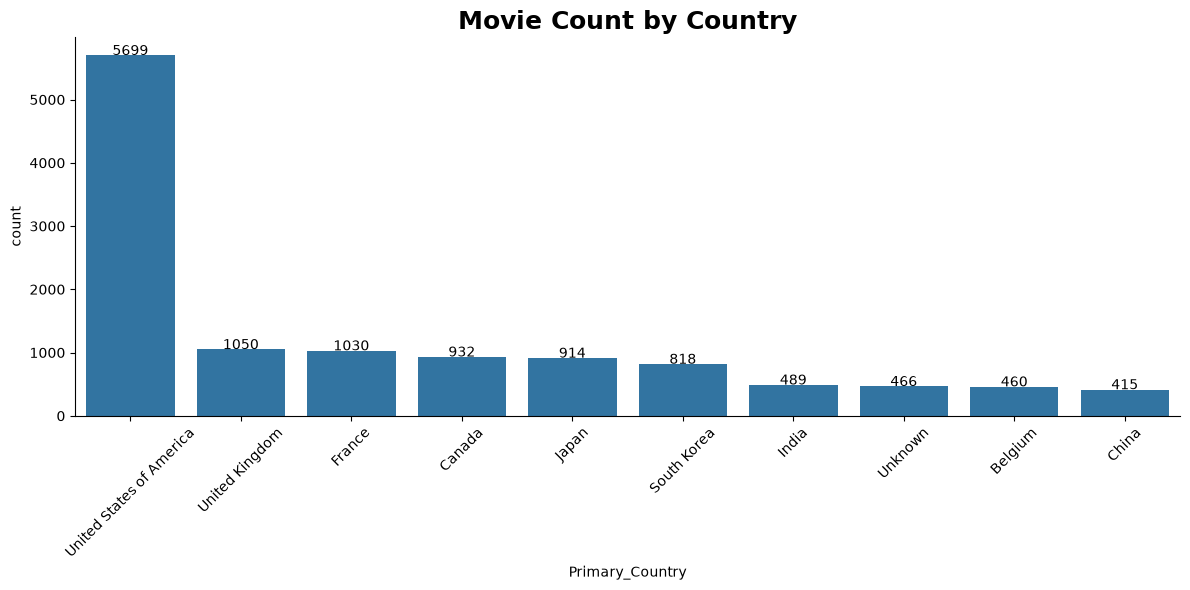

In [25]:
Country= (
    df_new['Primary_Country']
    .value_counts()
    .reset_index().head(10)
)

Country.columns = ['Primary_Country', 'count']

plt.figure(figsize=(12,6))

sns.barplot(
    data=Country,
    x='Primary_Country',
    y='count'
)

plt.title('Movie Count by Country', fontsize=18, weight='bold')
plt.xticks(rotation=45)

for i, v in enumerate(Country['count']):
    plt.text(i, v+5, str(v), ha='center')

sns.despine()
plt.tight_layout()
plt.show()

**Language Representation**

This chart shows the most common movie languages in the dataset. It provides another perspective on how globally diverse the catalog is.

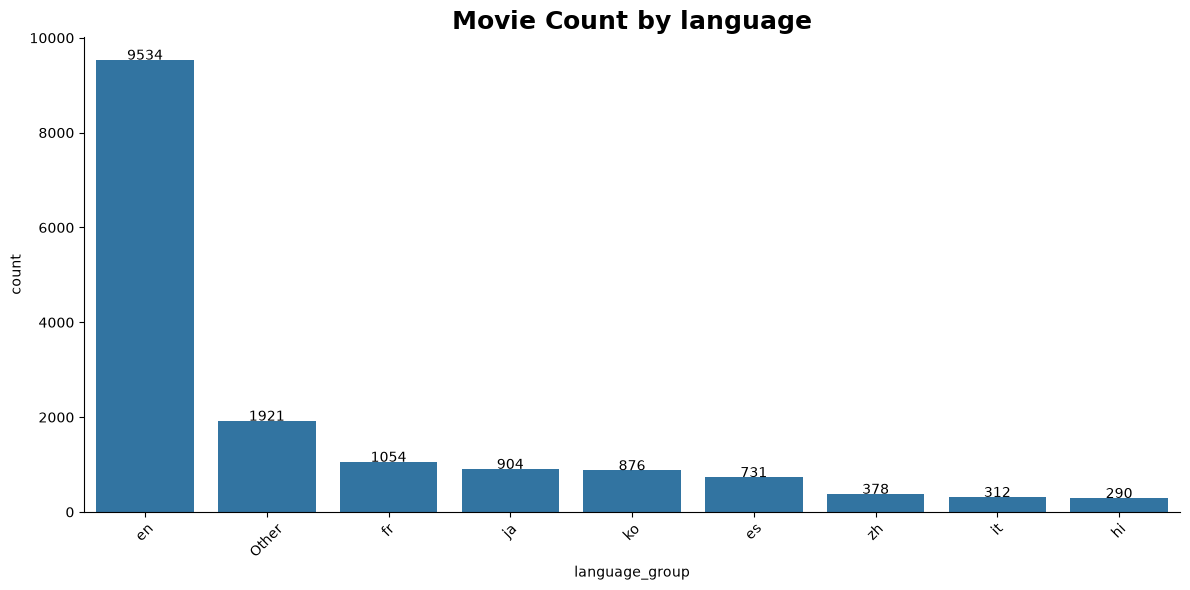

In [26]:
language= (
    df_new['language_group']
    .value_counts()
    .reset_index().head(10)
)

language.columns = ['language_group', 'count']

plt.figure(figsize=(12,6))

sns.barplot(
    data=language,
    x='language_group',
    y='count'
)

plt.title('Movie Count by language', fontsize=18, weight='bold')
plt.xticks(rotation=45)

for i, v in enumerate(language['count']):
    plt.text(i, v+5, str(v), ha='center')

sns.despine()
plt.tight_layout()
plt.show()

**Genre Representation**

This chart shows which primary genres appear most frequently. It highlights whether the catalog is shaped mainly by a small number of familiar entertainment genres.

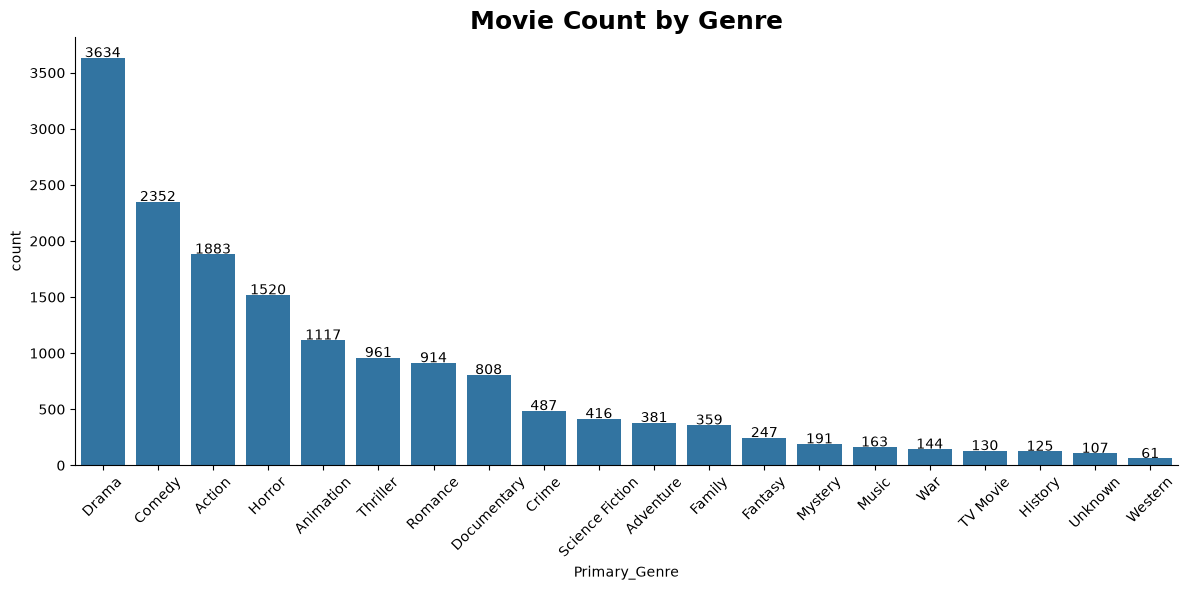

In [27]:
genre = (
    df_new['Primary_Genre']
    .value_counts()
    .reset_index()
)

genre.columns = ['Primary_Genre', 'count']

plt.figure(figsize=(12,6))

sns.barplot(
    data=genre,
    x='Primary_Genre',
    y='count'
)

plt.title('Movie Count by Genre', fontsize=18, weight='bold')
plt.xticks(rotation=45)

for i, v in enumerate(genre['count']):
    plt.text(i, v+5, str(v), ha='center')

sns.despine()
plt.tight_layout()
plt.show()

**Diversity Across Release Periods**

This chart compares the number of unique countries and languages across release periods. It shows whether movie representation became more diverse between 2010 and 2025.

In [28]:
diversity = df_new.groupby("Period", observed=True).agg(
    unique_countries=("Primary_Country", "nunique"),
    unique_languages=("language", "nunique")
).reset_index()

diversity

,Period,unique_countries,unique_languages
0,2010-14,76,48
1,2015-19,84,54
2,2020-25,99,70


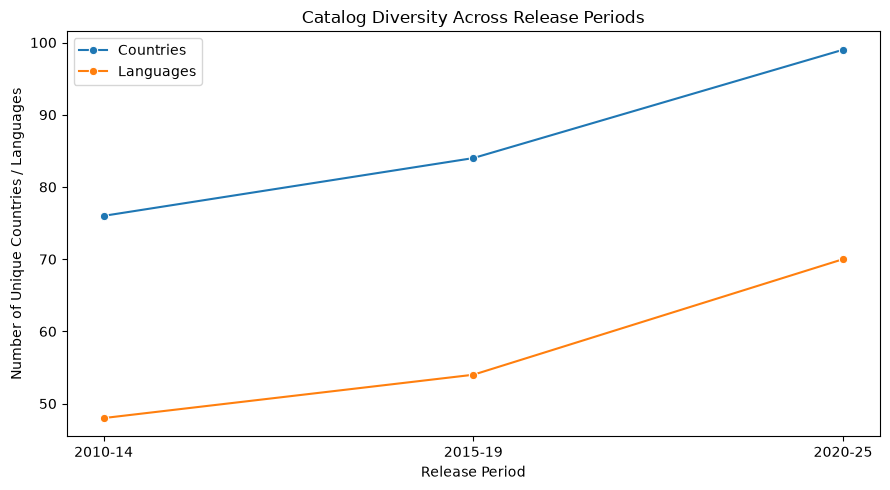

In [29]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=diversity,
    x="Period",
    y="unique_countries",
    marker="o",
    label="Countries"
)

sns.lineplot(
    data=diversity,
    x="Period",
    y="unique_languages",
    marker="o",
    label="Languages"
)

plt.title("Catalog Diversity Across Release Periods")
plt.xlabel("Release Period")
plt.ylabel("Number of Unique Countries / Languages")
plt.tight_layout()
plt.show()

**Audience Ratings by Country**

This chart compares median audience ratings across countries with at least 20 movies. The minimum threshold prevents countries with very few films from producing misleading rankings.

In [30]:
country_ratings = (
    df_new.groupby("Primary_Country")
    .agg(
        movies=("title", "count"),
        median_rating=("vote_average", "median")
    )
    .query("movies >= 20")
    .sort_values("median_rating", ascending=False)
    .head(10)
    .reset_index()
)

country_ratings

,Primary_Country,movies,median_rating
0,Mexico,189,6.900
1,Japan,914,6.900
2,Colombia,33,6.896
3,Denmark,142,6.700
4,Czech Republic,36,6.650
5,Argentina,111,6.600
6,Brazil,155,6.600
7,India,489,6.500
8,Taiwan,37,6.500
9,South Korea,818,6.500


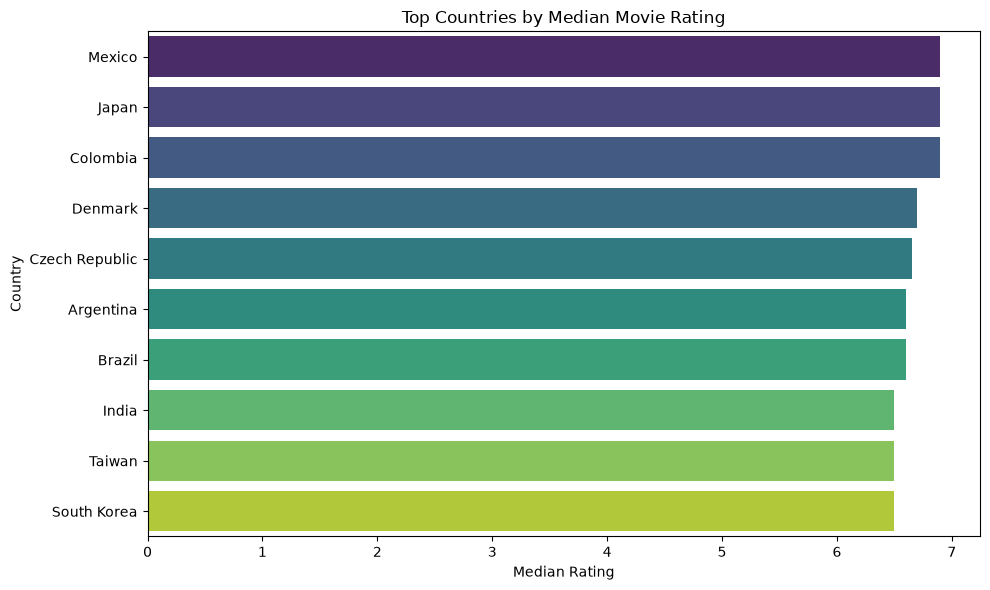

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=country_ratings,
    x="median_rating",
    y="Primary_Country",
    hue="Primary_Country",
    legend=False,
    palette="viridis"
)

plt.title("Top Countries by Median Movie Rating")
plt.xlabel("Median Rating")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

**Audience Engagement by Genre**

This chart compares median audience engagement across genres using log-transformed vote counts. It shows which genres tend to generate the strongest typical audience participation.

In [35]:
genre_engagement = (
    df_new.groupby("Primary_Genre")
    .agg(
        movies=("title", "count"),
        median_engagement=("vote_engagement", "median")
    )
    .query("movies >= 20")
    .sort_values("median_engagement", ascending=False)
    .head(10)
    .reset_index()
)

country_ratings

,Primary_Country,movies,median_rating
0,Mexico,189,6.900
1,Japan,914,6.900
2,Colombia,33,6.896
3,Denmark,142,6.700
4,Czech Republic,36,6.650
5,Argentina,111,6.600
6,Brazil,155,6.600
7,India,489,6.500
8,Taiwan,37,6.500
9,South Korea,818,6.500


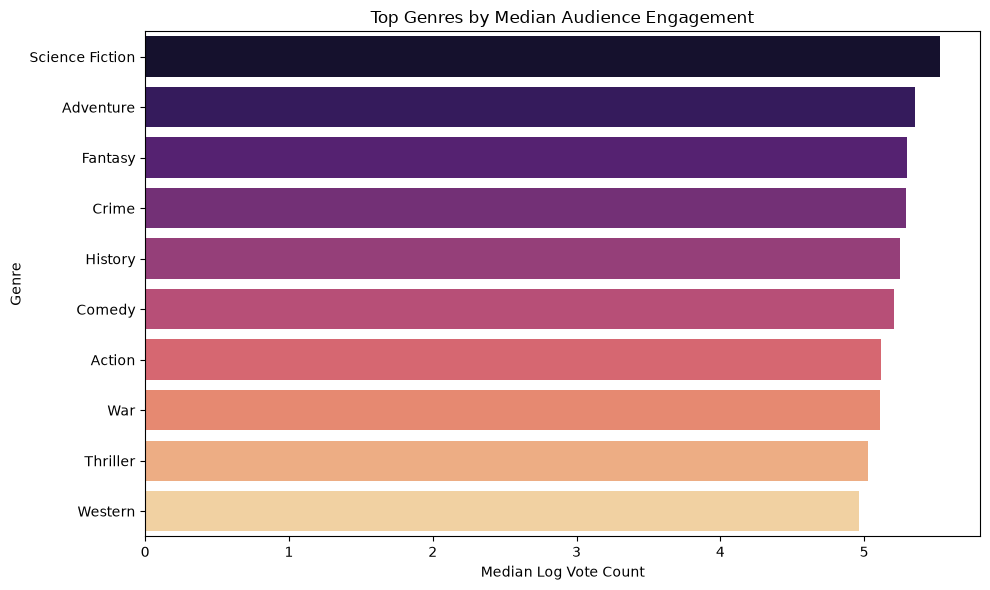

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_engagement,
    x="median_engagement",
    y="Primary_Genre",
    hue="Primary_Genre",
    legend=False,
    palette="magma"
)

plt.title("Top Genres by Median Audience Engagement")
plt.xlabel("Median Log Vote Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

**US Share Across Release Periods**

This chart compares the share of movies from the United States with movies from all other countries. It directly addresses whether global representation has become more balanced over time.

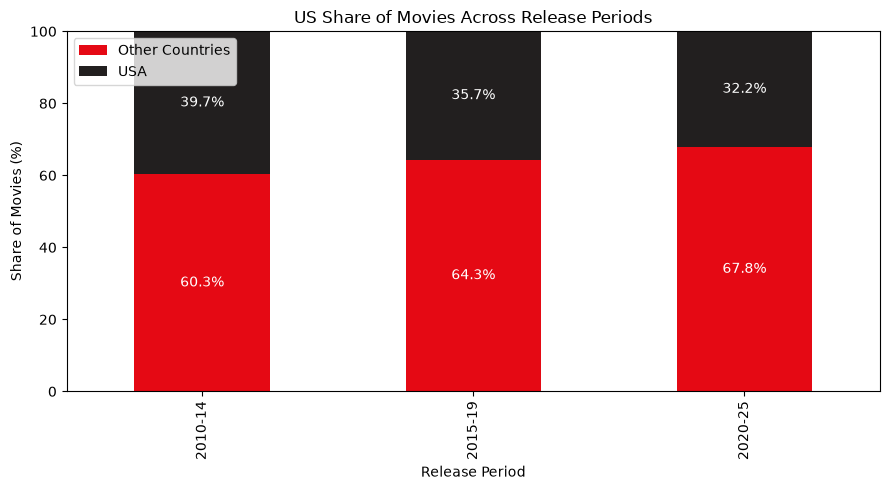

In [43]:
df_new['Country_Group']=np.where(df_new['Primary_Country']=='United States of America','USA','Other Countries')
country_share=pd.crosstab(df_new['Period'],df_new['Country_Group'],normalize='index')*100
ax = country_share.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=["#E50914", "#221F1F"]
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() >= 5 else ""
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=10
    )
plt.title("US Share of Movies Across Release Periods")
plt.xlabel("Release Period")
plt.ylabel("Share of Movies (%)")
plt.legend(title="")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Budget and Revenue**

This scatter plot examines the relationship between reported production budget and reported revenue. Both axes use a logarithmic scale because financial values vary substantially across movies.

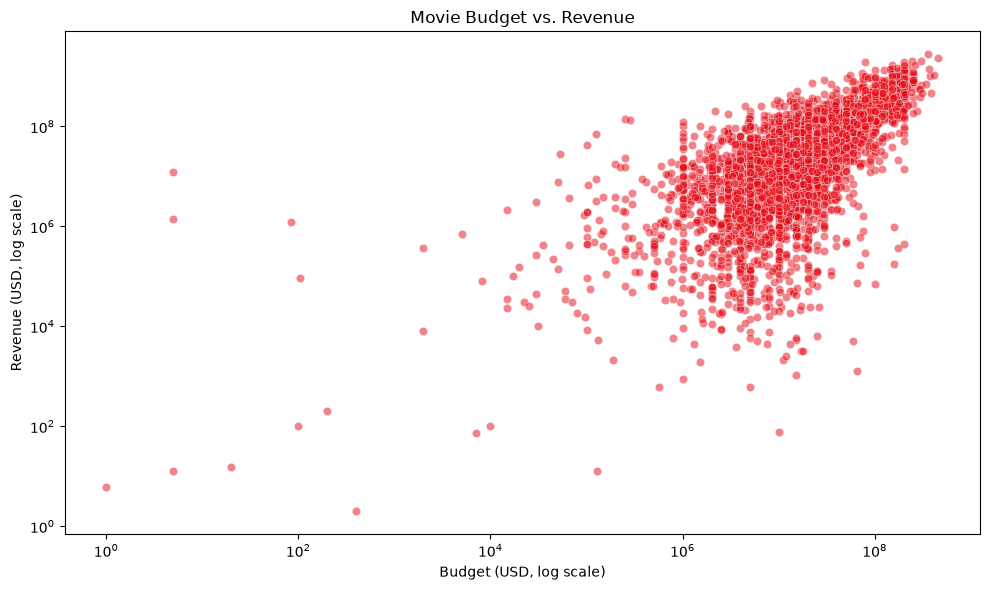

In [46]:
financial_movies=df_new[(df_new['Rev_bud'])&(df_new['budget']>0)&(df_new['revenue']>0)]
plt.figure(figsize=(10,6))
sns.scatterplot(data=financial_movies,
    x="budget",
    y="revenue",
    alpha=0.5,
    color="#E50914"
)

plt.xscale("log")
plt.yscale("log")

plt.title("Movie Budget vs. Revenue")
plt.xlabel("Budget (USD, log scale)")
plt.ylabel("Revenue (USD, log scale)")
plt.tight_layout()
plt.show()

**ROI by Budget Band**

This chart compares return on investment across low-, medium-, and high-budget movies. Extreme ROI values are capped only for visualization, so they do not make the chart unreadable.

C:\Users\Asus\AppData\Local\Temp\ipykernel_13480\4060911016.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


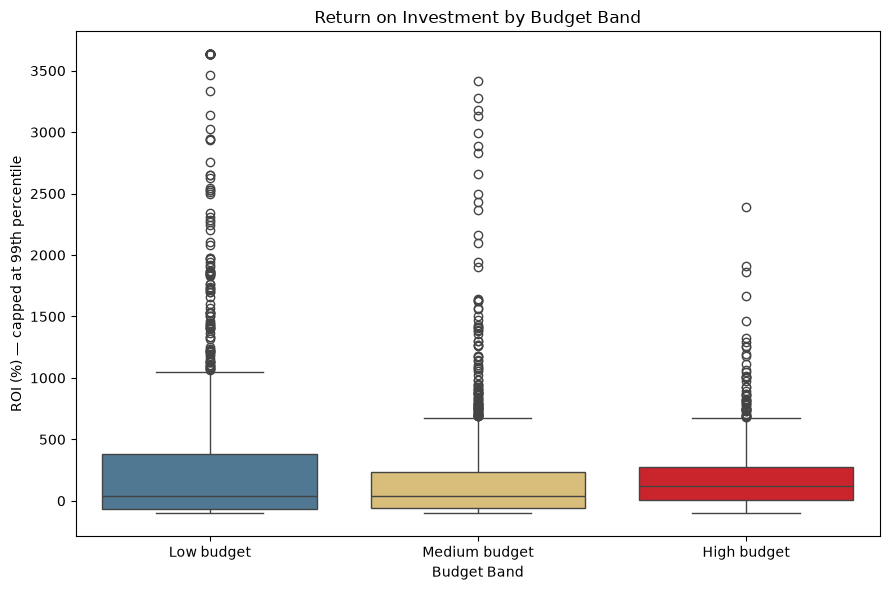

In [49]:
roi_data = df_new[
    (df_new["Rev_bud"]) &
    (df_new["budget_band"].isin(
        ["Low budget", "Medium budget", "High budget"]
    ))
].copy()

# Cap only the chart values at the 99th percentile to reduce extreme outliers
upper_limit = roi_data["Roi_Percent"].quantile(0.99)
roi_data["roi_for_chart"] = roi_data["Roi_Percent"].clip(upper=upper_limit)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=roi_data,
    x="budget_band",
    y="roi_for_chart",
    order=["Low budget", "Medium budget", "High budget"],
    palette=["#457B9D", "#E9C46A", "#E50914"]
)

plt.title("Return on Investment by Budget Band")
plt.xlabel("Budget Band")
plt.ylabel("ROI (%) — capped at 99th percentile")
plt.tight_layout()
plt.show()

**Key Findings**

● The movie dataset is internationally represented, but production is concentrated in a small number of countries and languages.

● The United States and English-language movies have a major presence across the release periods.

● Drama, comedy, and other popular genres account for a large share of movies, while some less common genres generate stronger audience engagement.

● Science Fiction has the highest median audience engagement among the leading genres in this analysis.

● Higher movie budgets are generally associated with higher revenue, but they do not automatically guarantee the strongest return on investment.

**Limitations**

● Primary_Country and Primary_Genre use the first value listed for a movie. This simplifies co-productions and multi-genre films.

● Budget and revenue information is available for only 3,540 movies, so financial findings apply only to that subset.

● Revenue minus budget is a simplified profit measure. It does not include marketing, distribution, or other costs.

● Vote counts and ratings represent available audience-metadata measures. They should not be interpreted as Netflix viewing hours or subscriber behavior.

**Conclusion**

The dataset shows that Netflix movies have international representation, but the catalog remains strongly influenced by a few leading countries, languages, and genres. Audience engagement is not limited to the most common genres; for example, Science Fiction receives the strongest typical voting engagement. Financial results also suggest that large budgets can generate large revenues, but higher spending does not necessarily produce the best return on investment. Overall, the analysis shows a catalog with global participation but continued concentration in major production markets.